In [1]:
import os, sys
import glob

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import tensorflow as tf
import keras 

In [2]:
print(f"Keras version: {keras.__version__}")
print(f"TensorFlow version: {tf.__version__}")

Keras version: 3.11.3
TensorFlow version: 2.20.0


In [3]:
RANDOM_STATE = 42
IMAGE_SHAPE = (48, 48)
INPUT_SHAPE = (48, 48, 1)
EPOCHS = 100
BATCH_SIZE = 32
NUM_CLASSES = 3

In [4]:
os.getcwd()

'/Users/rishijaiswal/Downloads/project code'

In [5]:
os.listdir("../../data")

['.DS_Store', 'test', 'train', 'val']

In [6]:
os.listdir("/Users/rishijaiswal/Downloads/project code/data/train")

['.DS_Store', 'alert', 'yawning', 'microsleep']

In [7]:
train_path = r'/Users/rishijaiswal/Downloads/project code/data/train'
val_path = r'/Users/rishijaiswal/Downloads/project code/data/val'
test_path = r'/Users/rishijaiswal/Downloads/project code/data/test'

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
# augmenting images for training set
datagen = ImageDataGenerator(
    rescale = 1./255, 
    rotation_range = 15, 
    width_shift_range = 10,
    height_shift_range = 10, 
    shear_range = 0.15,
    zoom_range = 0.15,
    horizontal_flip = True,
)

# only normalizing the pixel values for the testing set
test_datagen = ImageDataGenerator(rescale = 1./255)

In [10]:
# read the data from directory 
train_gen = datagen.flow_from_directory(
    train_path, 
    target_size = IMAGE_SHAPE,
    batch_size = BATCH_SIZE, 
    color_mode = 'grayscale',
    class_mode = 'categorical',
    shuffle = True
)

val_gen = datagen.flow_from_directory(
    val_path, 
    target_size = IMAGE_SHAPE,
    batch_size = BATCH_SIZE, 
    color_mode = 'grayscale',
    class_mode = 'categorical',
    shuffle = True
)

test_gen = test_datagen.flow_from_directory(
    test_path, 
    target_size = IMAGE_SHAPE,
    batch_size = BATCH_SIZE, 
    color_mode = 'grayscale',
    class_mode = 'categorical',
    shuffle = False,
)

Found 48327 images belonging to 3 classes.
Found 2502 images belonging to 3 classes.
Found 2502 images belonging to 3 classes.


In [11]:
classes = ['alert', 'microsleep', 'yawning']

Class [0 1 2]
Count [35483  8074  4770]



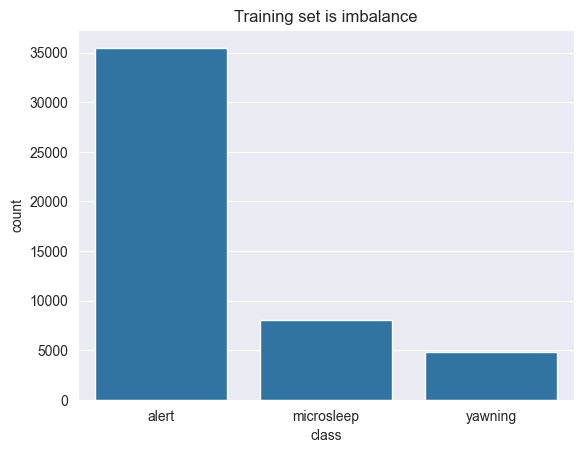

In [12]:
class_count = np.unique(train_gen.classes, return_counts = True)

print("Class", class_count[0])
print("Count", class_count[1])
print()

plt.figure()

sns.barplot(x = classes, y = class_count[1])

plt.title("Training set is imbalance")
plt.xlabel('class')
plt.ylabel('count') 
plt.show()

In [13]:
from sklearn.utils.class_weight import compute_class_weight

In [14]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_labels = np.unique(train_gen.classes)
class_weight_dict = dict(zip(class_labels, class_weights))
class_weights

array([0.45399205, 1.99516968, 3.37714885])

In [15]:
class_weight_dict

{np.int32(0): np.float64(0.45399205253219854),
 np.int32(1): np.float64(1.995169680455784),
 np.int32(2): np.float64(3.377148846960168)}

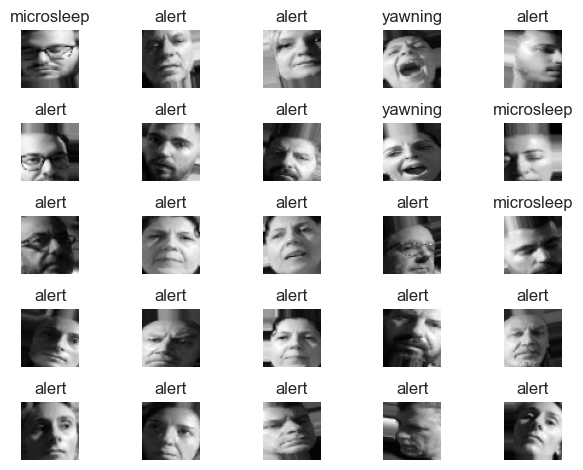

In [16]:
fig, axes = plt.subplots(ncols = 5, nrows = 5)
axes =axes.flatten()

for i in range(25):
    j = np.random.randint(train_gen.n)

    # take data 
    batch_images, batch_labels = train_gen[j // BATCH_SIZE]
    id_in_batch = j % BATCH_SIZE 
    image = batch_images[id_in_batch]
    label = batch_labels[id_in_batch].argmax()

    # show data
    axes[i].imshow(image, cmap = "gray")
    axes[i].set_title(classes[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(48,48,1)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.SpatialDropout2D(0.2),
    
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.SpatialDropout2D(0.2),
    
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.SpatialDropout2D(0.2),
    
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(3, activation='softmax')
])

optimizer = keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

/Users/rishijaiswal/Downloads/project code/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 24, 24, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 12, 12, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 6, 6, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,04

 Total params: 489,443 (1.87 MB)

 Trainable params: 487,011 (1.86 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [19]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
callbacks = [early_stopping, lr_scheduler]

In [20]:
model.fit(train_gen, epochs=100, validation_data=val_gen,class_weight=class_weight_dict, callbacks = callbacks)

Epoch 1/100


/Users/rishijaiswal/Downloads/project code/venv/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1511/1511 ━━━━━━━━━━━━━━━━━━━━ 308s 200ms/step - accuracy: 0.6143 - loss: 0.6902 - val_accuracy: 0.8537 - val_loss: 0.3623 - learning_rate: 0.0010
Epoch 2/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 279s 184ms/step - accuracy: 0.8339 - loss: 0.3194 - val_accuracy: 0.9305 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 3/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 277s 183ms/step - accuracy: 0.9105 - loss: 0.1933 - val_accuracy: 0.9269 - val_loss: 0.1816 - learning_rate: 0.0010
Epoch 4/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 277s 183ms/step - accuracy: 0.9281 - loss: 0.1520 - val_accuracy: 0.9225 - val_loss: 0.2203 - learning_rate: 0.0010
Epoch 5/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 276s 183ms/step - accuracy: 0.9398 - loss: 0.1283 - val_accuracy: 0.9388 - val_loss: 0.1615 - learning_rate: 0.0010
Epoch 6/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 291s 193ms/step - accuracy: 0.9437 - loss: 0.1193 - val_accuracy: 0.9305 - val_loss: 0.1776 - learning_rate: 0.0010
Epoch 7/100
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 274s 182ms/step

In [21]:
model.save('fl3d_model_3.keras')

In [22]:
model.save('fl3d_model_whts_3.h5')

In [23]:
from IPython.display import FileLink

# Provide the path to your saved model file
file_path = "/kaggle/working/fl3d_model_3.keras"

# Create a downloadable link
FileLink(file_path)

/kaggle/working/fl3d_model_3.keras

In [24]:
# Provide the path to your saved model file
file_path_2 = "/kaggle/working/fl3d_model_whts_3.h5"

# Create a downloadable link
FileLink(file_path_2)

/kaggle/working/fl3d_model_whts_3.h5

In [25]:
score = model.evaluate(test_gen, verbose=1)
print(f"Test loss: {score[0]:.4f}")
print(f"Test accuracy: {score[1]:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9820 - loss: 0.0521
Test loss: 0.0521
Test accuracy: 0.9820


In [26]:
pred_y = model.predict(test_gen)
pred_label = np.argmax(pred_y, axis=1)

true_label = test_gen.classes

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


In [27]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

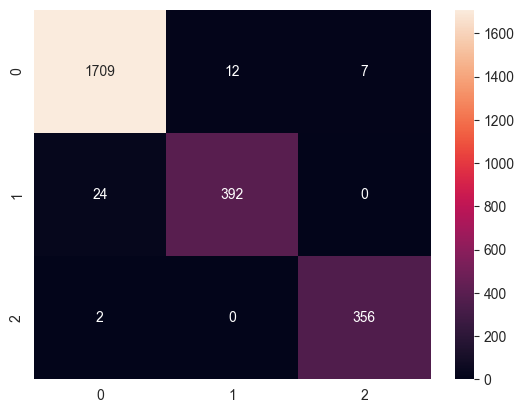

In [28]:
cfs_mt = confusion_matrix(true_label, pred_label)

plt.figure()

sns.heatmap(cfs_mt, annot = True, fmt = 'd')

plt.show()

In [29]:
print(classification_report(true_label, pred_label))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1728
           1       0.97      0.94      0.96       416
           2       0.98      0.99      0.99       358

    accuracy                           0.98      2502
   macro avg       0.98      0.98      0.98      2502
weighted avg       0.98      0.98      0.98      2502



In [30]:
f1_scores = f1_score(true_label, pred_label, average=None)

f1_data = pd.DataFrame({
    'Class': classes,
    'F1-Score': f1_scores
})

In [31]:
f1_macro = f1_score(true_label, pred_label, average='macro')
print(f"F1-score macro: {f1_macro}")

F1-score macro: 0.9768734615266154


In [32]:
f1_data

,Class,F1-Score
0,alert,0.987005
1,microsleep,0.956098
2,yawning,0.987517


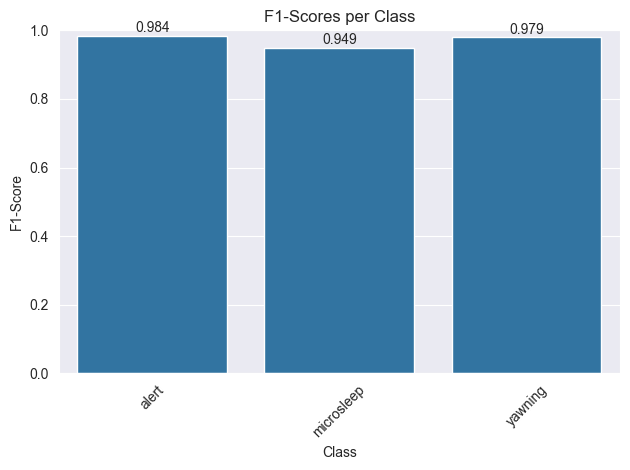

In [37]:
plt.figure()

sns.barplot(data=f1_data, x='Class', y='F1-Score')

plt.title('F1-Scores per Class')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# add data label
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

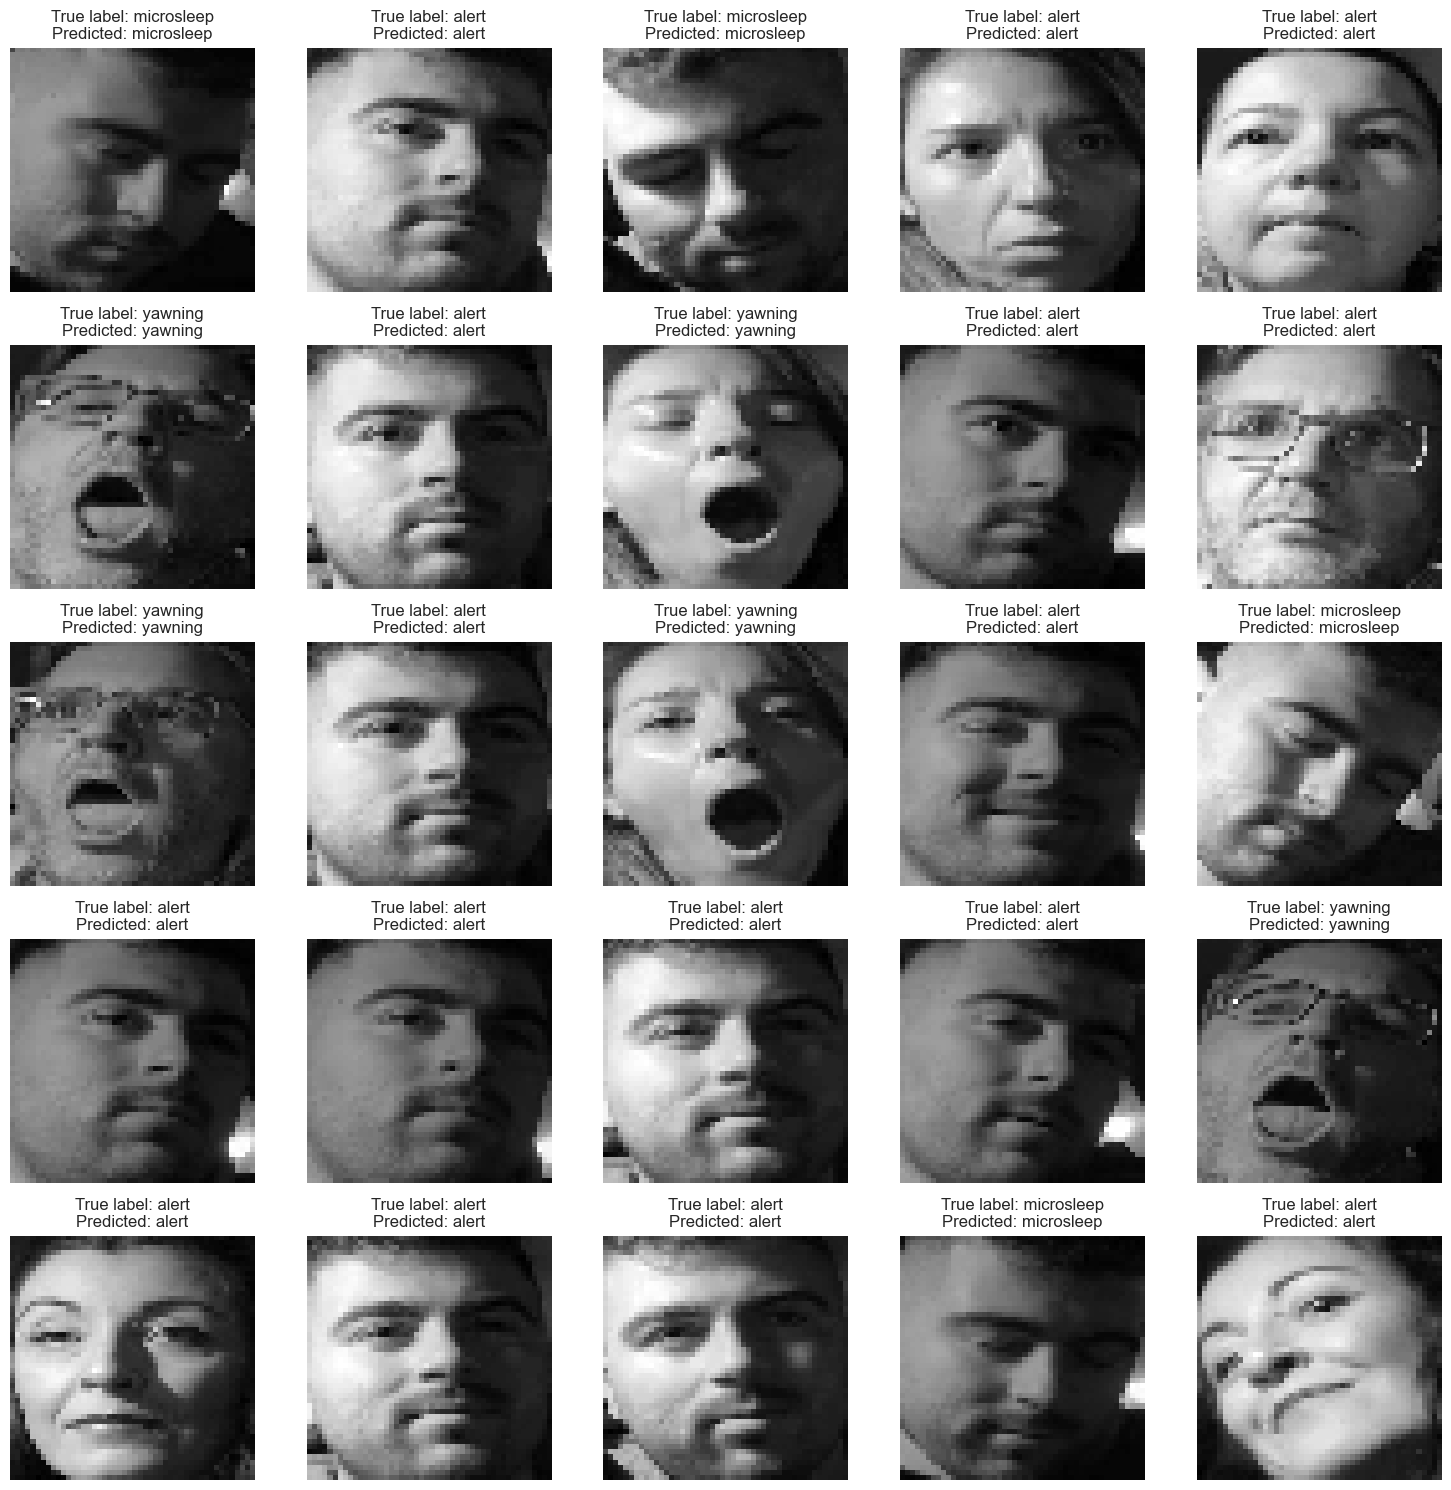

In [33]:
# show 25 random test image and model predictions of them
fig, axes = plt.subplots(ncols = 5, nrows = 5, figsize = (15, 15))
axes =axes.flatten()

for i in range(25):
    j = np.random.randint(test_gen.n)

    # take data 
    batch_images, batch_labels = test_gen[j // BATCH_SIZE]
    id_in_batch = j % BATCH_SIZE 
    image = batch_images[id_in_batch]
    label = batch_labels[id_in_batch].argmax()

    # show data
    axes[i].imshow(image, cmap = "gray")
    axes[i].set_title(f"True label: {classes[label]}\nPredicted: {classes[pred_label[j]]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()